# 05 — Logistic Regression & Credit Risk Modeling

## Objective

Build an interpretable borrower-level probability-of-default model and use it to understand the drivers of simulated credit risk.

The model is designed for **interpretability**, not only predictive accuracy. This notebook connects statistical analysis with practical credit-risk modeling.

### Modeling goals

- Predict borrower default probability
- Quantify feature effects using odds ratios
- Evaluate discrimination with ROC-AUC and PR-AUC
- Evaluate classification performance
- Examine probability calibration
- Compare model risk across borrower segments

> **Important:** The policy experiment itself was randomized. This model is a separate predictive analysis and should not be interpreted as causal evidence about individual borrower characteristics.


## 1. Imports and load data


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "credit_policy_experiment.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run Notebook 01 first."
    )

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")


Rows: 1,302,848
Columns: 17


## 2. Define the modeling target

The target is the **simulated default outcome** generated in Notebook 01.

We intentionally do not use:

- `policy_pd`
- `baseline_pd`
- `approved`
- `policy_group`

as model predictors.

These variables are downstream of the experiment or directly encode the simulated policy mechanism and would create leakage.

The model therefore learns borrower risk from observable borrower/application characteristics.


In [2]:
TARGET = "simulated_default"

candidate_features = [
    "annual_income",
    "loan_amount",
    "dti_ratio",
    "employment_years",
    "interest_rate",
    "term",
    "grade"
]

features = [
    col for col in candidate_features
    if col in df.columns
]

print("Model features:")
for feature in features:
    print("-", feature)

print(f"\nNumber of features: {len(features)}")


Model features:
- annual_income
- loan_amount
- dti_ratio
- employment_years
- interest_rate
- term
- grade

Number of features: 7


## 3. Prepare the modeling dataset


In [3]:
model_df = df[features + [TARGET]].copy()

model_df = model_df.dropna(
    subset=[TARGET]
)

X = model_df[features]
y = model_df[TARGET].astype(int)

print(f"Modeling rows: {len(model_df):,}")
print(f"Default rate: {y.mean():.2%}")


Modeling rows: 1,302,848
Default rate: 19.51%


## 4. Train/test split

We use a stratified split so that the default rate remains approximately consistent across training and test sets.

The test set is held out until final evaluation.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")

print(
    f"\nTraining default rate: {y_train.mean():.2%}"
)

print(
    f"Test default rate:     {y_test.mean():.2%}"
)


Training rows: 1,042,278
Test rows:     260,570

Training default rate: 19.51%
Test default rate:     19.51%


## 5. Identify numeric and categorical features


In [5]:
numeric_features = [
    col for col in [
        "annual_income",
        "loan_amount",
        "dti_ratio",
        "employment_years",
        "interest_rate"
    ]
    if col in features
]

categorical_features = [
    col for col in [
        "term",
        "grade"
    ]
    if col in features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['annual_income', 'loan_amount', 'dti_ratio', 'employment_years', 'interest_rate']

Categorical features:
['term', 'grade']


## 6. Build the preprocessing pipeline


In [6]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


## 7. Train logistic regression


In [7]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight=None,
    random_state=42
)

model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        logistic_model
    )
])

model.fit(
    X_train,
    y_train
)

print("Logistic regression trained successfully.")


Logistic regression trained successfully.


## 8. Generate test-set probabilities


In [8]:
y_proba = model.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_proba >= 0.50
).astype(int)

print(
    f"Predicted probability range: "
    f"{y_proba.min():.4f} to {y_proba.max():.4f}"
)


Predicted probability range: 0.0000 to 0.9530


## 9. Model discrimination metrics


In [9]:
roc_auc = roc_auc_score(
    y_test,
    y_proba
)

pr_auc = average_precision_score(
    y_test,
    y_proba
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

brier = brier_score_loss(
    y_test,
    y_proba
)

metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Brier score"
    ],
    "Value": [
        roc_auc,
        pr_auc,
        accuracy,
        precision,
        recall,
        f1,
        brier
    ]
})

display(metrics)


,Metric,Value
0,ROC-AUC,0.649567
1,PR-AUC,0.309999
2,Accuracy,0.805933
3,Precision,0.676671
4,Recall,0.009759
5,F1,0.019240
6,Brier score,0.149648


## 10. Confusion matrix


In [10]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual non-default", "Actual default"],
    columns=["Predicted non-default", "Predicted default"]
)

display(cm_df)


,Predicted non-default,Predicted default
Actual non-default,209506,237
Actual default,50331,496


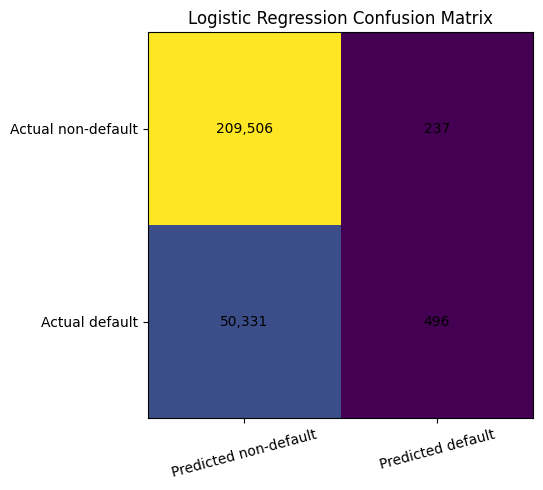

In [11]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    [0, 1],
    ["Predicted non-default", "Predicted default"],
    rotation=15
)

plt.yticks(
    [0, 1],
    ["Actual non-default", "Actual default"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()


## 11. ROC curve


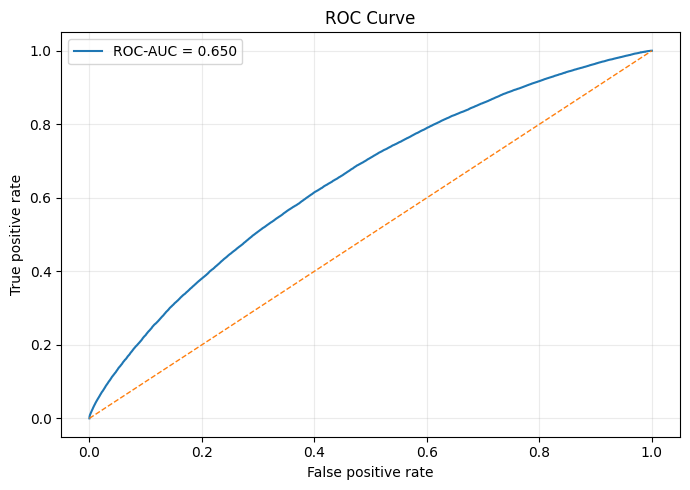

In [12]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 12. Precision-recall curve


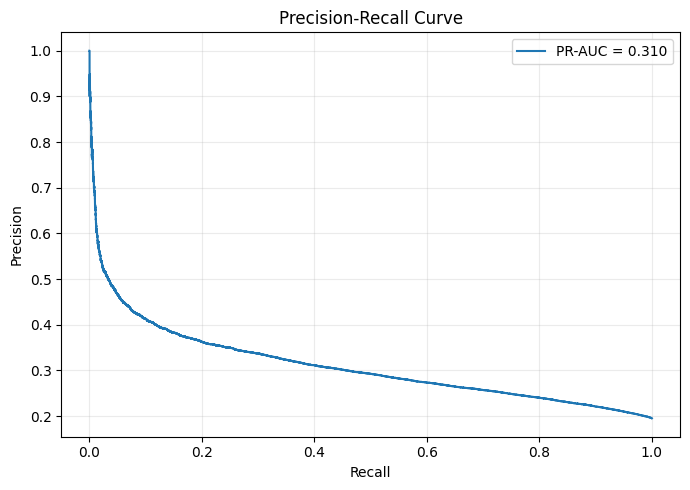

In [13]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 13. Extract logistic-regression coefficients and odds ratios

The model uses standardized numeric features. Therefore, numeric coefficients represent the change in log-odds associated with approximately one standard deviation increase in that variable, holding other variables constant.


In [14]:
fitted_preprocessor = model.named_steps["preprocessor"]
fitted_classifier = model.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

coefficients = fitted_classifier.coef_[0]

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

coef_table["abs_coefficient"] = (
    coef_table["coefficient"].abs()
)

coef_table = (
    coef_table
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .drop(columns="abs_coefficient")
)

display(coef_table)


,feature,coefficient,odds_ratio
0,numeric__annual_income,-0.481700,0.617732
2,numeric__dti_ratio,0.413985,1.512834
1,numeric__loan_amount,0.156473,1.169379
10,categorical__grade_F,-0.140490,0.868932
11,categorical__grade_G,-0.119427,0.887429
9,categorical__grade_E,-0.067023,0.935174
8,categorical__grade_D,-0.052953,0.948424
7,categorical__grade_C,-0.043220,0.957701
6,categorical__grade_B,-0.033614,0.966945
4,numeric__interest_rate,0.028879,1.029300


## 14. Interpret the strongest model drivers


In [15]:
top_positive = (
    coef_table
    .sort_values("coefficient", ascending=False)
    .head(5)
)

top_negative = (
    coef_table
    .sort_values("coefficient", ascending=True)
    .head(5)
)

print("Features associated with higher modeled default odds:")
display(top_positive)

print("\nFeatures associated with lower modeled default odds:")
display(top_negative)

print(
    "\nInterpretation note: odds ratios describe association within "
    "the predictive model. They should not be interpreted as causal effects."
)


Features associated with higher modeled default odds:


,feature,coefficient,odds_ratio
2,numeric__dti_ratio,0.413985,1.512834
1,numeric__loan_amount,0.156473,1.169379
4,numeric__interest_rate,0.028879,1.029300
5,categorical__term_ 60 months,0.007954,1.007986
3,numeric__employment_years,-0.010054,0.989997



Features associated with lower modeled default odds:


,feature,coefficient,odds_ratio
0,numeric__annual_income,-0.481700,0.617732
10,categorical__grade_F,-0.140490,0.868932
11,categorical__grade_G,-0.119427,0.887429
9,categorical__grade_E,-0.067023,0.935174
8,categorical__grade_D,-0.052953,0.948424



Interpretation note: odds ratios describe association within the predictive model. They should not be interpreted as causal effects.


## 15. Probability calibration

A credit-risk model should not only rank borrowers correctly; its probabilities should also be reasonably calibrated.


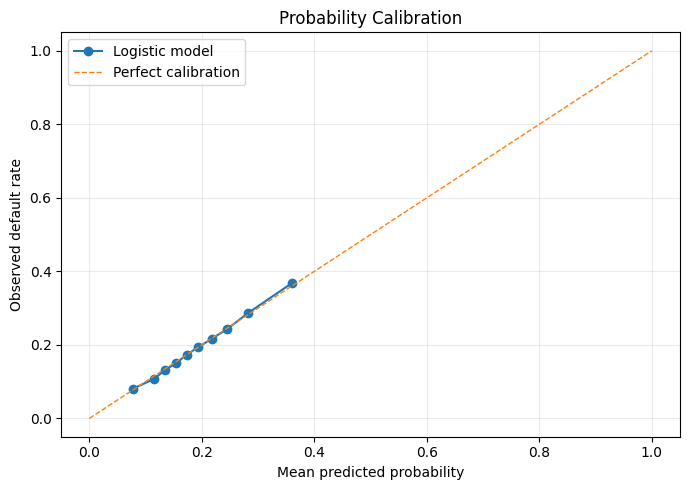

In [16]:
prob_true, prob_pred = calibration_curve(
    y_test,
    y_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Logistic model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.title("Probability Calibration")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 16. Risk deciles

Rank borrowers by predicted probability and compare average predicted PD with observed default rate. This is useful for credit-risk segmentation and dashboarding.


In [17]:
test_results = X_test.copy()

test_results["actual_default"] = y_test.to_numpy()
test_results["predicted_pd"] = y_proba

test_results["risk_decile"] = pd.qcut(
    test_results["predicted_pd"],
    q=10,
    labels=[
        "D1 Lowest",
        "D2",
        "D3",
        "D4",
        "D5",
        "D6",
        "D7",
        "D8",
        "D9",
        "D10 Highest"
    ],
    duplicates="drop"
)

risk_deciles = (
    test_results
    .groupby(
        "risk_decile",
        observed=True
    )
    .agg(
        borrowers=("actual_default", "size"),
        average_predicted_pd=("predicted_pd", "mean"),
        observed_default_rate=("actual_default", "mean")
    )
    .reset_index()
)

display(risk_deciles)


,risk_decile,borrowers,average_predicted_pd,observed_default_rate
0,D1 Lowest,26057,0.078060,0.081091
1,D2,26057,0.114375,0.106689
2,D3,26057,0.134957,0.132133
3,D4,26057,0.153895,0.149595
4,D5,26057,0.173193,0.173312
5,D6,26057,0.193769,0.193768
6,D7,26057,0.217153,0.216142
7,D8,26057,0.245042,0.243044
8,D9,26057,0.282521,0.286948
9,D10 Highest,26057,0.360104,0.367886


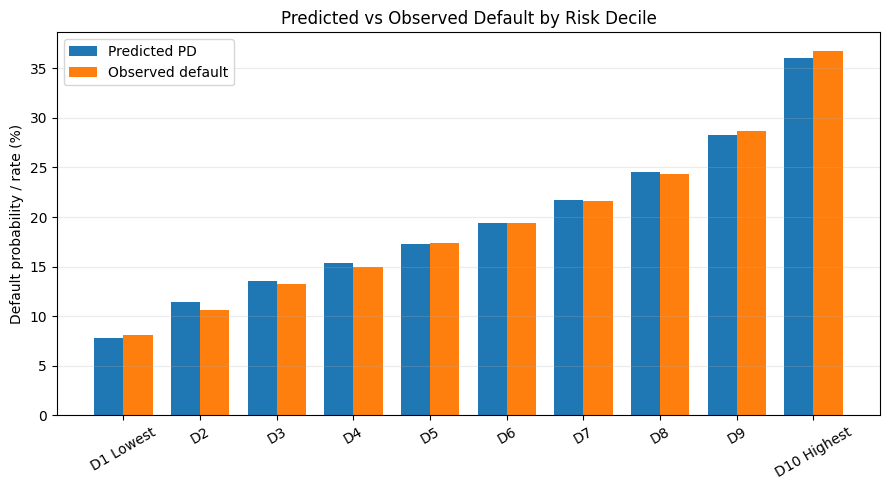

In [18]:
plt.figure(figsize=(9, 5))

x = np.arange(
    len(risk_deciles)
)

width = 0.38

plt.bar(
    x - width / 2,
    risk_deciles["average_predicted_pd"] * 100,
    width,
    label="Predicted PD"
)

plt.bar(
    x + width / 2,
    risk_deciles["observed_default_rate"] * 100,
    width,
    label="Observed default"
)

plt.xticks(
    x,
    risk_deciles["risk_decile"].astype(str),
    rotation=30
)

plt.ylabel("Default probability / rate (%)")
plt.title("Predicted vs Observed Default by Risk Decile")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


## 17. Model performance by policy group


In [19]:
test_results["policy_group"] = df.loc[
    X_test.index,
    "policy_group"
].to_numpy()

policy_model_metrics = (
    test_results
    .groupby("policy_group")
    .apply(
        lambda g: pd.Series({
            "borrowers": len(g),
            "average_predicted_pd": g["predicted_pd"].mean(),
            "observed_default_rate": g["actual_default"].mean(),
            "brier_score": brier_score_loss(
                g["actual_default"],
                g["predicted_pd"]
            )
        }),
        include_groups=False
    )
    .reset_index()
)

display(policy_model_metrics)


,policy_group,borrowers,average_predicted_pd,observed_default_rate,brier_score
0,control,130678.0,0.195204,0.201840,0.153808
1,treatment,129892.0,0.195410,0.188241,0.145462


## 18. Model limitations

This logistic regression is intentionally interpretable, but it has important limitations:

- The outcome is a **simulated default**, not a future real-world observation.
- The Lending Club dataset version used here does not contain FICO/credit-score fields.
- Model coefficients represent associations, not causal effects.
- A single train/test split does not replace full model validation.
- The 0.50 classification threshold is illustrative; production credit decisions require threshold optimization based on costs, regulatory constraints, and business objectives.
- Expected loss and policy economics are evaluated separately in Notebook 06.

The model is therefore best presented as an **interpretable credit-risk modeling component** of the project, not as a production underwriting model.


## 19. Modeling conclusions

The logistic regression provides an interpretable borrower-level risk model that complements the randomized policy experiment.

The experiment answers:

> **Does the simulated policy change default outcomes?**

The logistic model answers:

> **Which observable borrower characteristics are associated with higher predicted default risk, and how well can we rank borrowers by risk?**

The next step is to translate those probabilities into **Expected Loss = PD × LGD × EAD** and evaluate whether the reduction in defaults justifies the reduction in approvals.
